# <a href="https://thetahat.ru/courses/ph-ds-group">Phystech@DataScience</a>
## Домашнее задание 2. <font color="green">Профиль биология</font>

**Правила, <font color="red">прочитайте внимательно</font>:**

1. Общее

     * Выполненную работу **в формате `ipynb`** нужно отправить телеграм-боту `@thetahat_phds26_bot` согласно <a href="https://thetahat.ru/instructions-bot"><b>инструкции</b></a>. **Работы, присланные иным способом, не принимаются.** Дедлайны указаны в боте, они являются строгими. Переносы дедлайнов осуществляются по установленным <a href="https://thetahat.ru/deadlines"><b>правилам</b></a>.
     
     * Обязательно изучите <a href="https://thetahat.ru/courses/design-hw"><b>руководство по оформлению ДЗ</b></a>. В частности, оно содержит примеры случаев, когда могут быть снижены баллы.
     
     * Обратите внимание на <a href="https://thetahat.ru/courses/ai-rules"><b>правила использования ИИ-инструментов</b></a> при решении домашнего задания.
     
     * Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания (в т.ч. злоупотребление ИИ) всем участникам нужно будет сдавать устный зачет.**
     
     * Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
     </br>

2. Правила заполнения ноутбука

     * Запрещается удалять имеющиеся в ноутбуке ячейки, менять местами положения существующих ячеек.
     * Отвечайте на вопросы, а также добавляйте новые ячейки в любом количестве в предложенных местах, которые обозначены `<...>`.
     * Сохраняйте естественный линейный порядок повествования в ноутбуке сверху-вниз. Комментарии к решению пишите в markdown-ячейках.
     * Условия <font color="red"><b>запрещается модифицировать</b></font>.
     * При нарушении данных правил работа может получить 0 баллов.
</br>

**Баллы за задание:**

<b><font color="blue">Легкая часть</font></b> (достаточно на "хор"):
* Задача 1 &mdash; 30 баллов
* Задача 2 &mdash; 40 баллов
* Задача 3 &mdash; 30 баллов

<b><font color="orange">Сложная часть</font></b> (необходимо на "отл"):
* Задача 4 &mdash; 60 баллов

In [3]:
# Bot check

# HW_ID: phds_hw2
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: not final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

# Profile: Biology

### Ссылки на использование ИИ

Если при решении задач использовался ИИ, укажи здесь публичные ссылки на все чаты с ИИ и поясни, для каких целей он применялся. Обрати внимание на <a href="https://thetahat.ru/courses/ai-rules" target="_top">правила</a>.

**Задача 1**
1. ссылка
    - для чего использована
    - для чего использована
2. ссылка
    - для чего использована

**Задача 2**
1. ссылка
    - для чего использована


In [4]:
import numpy as np
import pandas as pd
from scipy.stats import norm

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from typing import Optional

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.base import BaseEstimator

import warnings
# warnings.filterwarnings("ignore")
import seaborn as sns
sns.set_theme(style="whitegrid")

## <font color="blue">Легкая часть</font>
   

### Задача 1

#### 1. Взвешенный метод наименьших квадратов (Weighted Least Squares)

[Взвешенный МНК](https://www.itl.nist.gov/div898/handbook/pmd/section1/pmd143.htm?utm_source=chatgpt.com) используют, когда наблюдения имеют разную точность: более «надежным» измерениям дают больший вес. В физических/инженерных экспериментах так учитывают неодинаковую погрешность приборов и точек съёмки — веса позволяют «подтянуть» оценку туда, где измерения точнее и тем самым улучшить параметры калибровки и оценки неопределённости. В медицине и биостатистике это стандарт в мета-анализах: эффект каждого исследования агрегируют с [инверсно-дисперсными весами](https://mentalhealth.bmj.com/content/17/2/64?utm_source=chatgpt.com), чтобы большие и более точные выборки сильнее влияли на общий вывод.

>❕**Замечание:**❕Вес обычно пропорционален корню из обратной дисперсии ошибки

Реализацию взвешенного МНК  есть в различных библиотеках, например: [`sklearn`](https://sklearn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html?utm_source=chatgpt.com#:~:text=dtype%20if%20necessary.-,sample_weight,-array%2Dlike%20of), [`statsmodels`](https://www.statsmodels.org/dev/generated/statsmodels.regression.linear_model.WLS.html?utm_source=chatgpt.com)

Во взвешенном методе наименьших квадратов каждому наблюдению задается некоторый известный вес $w_i$. Задача имеет вид: $$\sum\limits_{i=1}^n w_i\left(Y_i - x_i^T \theta\right)^2 \to \min\limits_\theta$$

* $Y\in\mathbb{R}^{n}$ — вектор отклика,
* $X\in\mathbb{R}^{n\times d}$ — матрица признаков (первая колонка может быть единичной для свободного члена),
* $\theta\in\mathbb{R}^{d}$ — параметры,
* $W=\mathrm{diag}(w_1,\dots,w_n)\in\mathbb{R}^{n\times n}$ — диагональная матрица **неотрицательных** весов.

Найдите решение задачи в матричном виде.

\\documentclass{article}
\usepackage[utf8]{inputenc}
\usepackage[T2A]{fontenc}
\usepackage[russian]{babel}
\usepackage{amsmath, amssymb}
\usepackage{geometry}
\geometry{
    left=2cm,      % левое поле
    right=2cm,     % правое поле
    top=2cm,       % верхнее поле
    bottom=2cm,    % нижнее поле
}
\begin{document}

\section*{Взвешенный метод наименьших квадратов }

\subsection*{Дано:}
\begin{itemize}
    \item $Y \in \mathbb{R}^n$ — вектор отклика
    \item $X \in \mathbb{R}^{n \times d}$ — матрица признаков
    \item $\theta \in \mathbb{R}^d$ — вектор параметров
    \item $W = \operatorname{diag}(w_1, \dots, w_n) \in \mathbb{R}^{n \times n}$ — диагональная матрица весов
\end{itemize}

Необходимо минимизировать взвешенную сумму квадратов:
\[
S(\theta) = \sum_{i=1}^n w_i (Y_i - x_i^T \theta)^2 \to \min_{\theta}
\]

\subsection*{Решение}
Хотим записать матричную форму целевой функции \\
Вектор ошибок можем переписать через заданные в условии вектора:
\[
e = Y - X\theta

Нам нужно:
\[
\sum_{i=1}^n w_i e_i^2
\]

Так как нам надо учитывать веса, нужно взвешенное скалярное произведение вектора $e$ на самого себя, где каждый компонент умножается на свой вес $w_i$.

В матричном виде запишем:
\[
e^T W e = \sum_{i=1}^n \sum_{j=1}^n e_i W_{ij} e_j
\]
Так как $W$ — диагональная, $W_{ij} = 0$ при $i \neq j$, а $W_{ii} = w_i$.

Значит, остаётся:
\[
e^T W e = \sum_{i=1}^n e_i \cdot w_i \cdot e_i = \sum_{i=1}^n w_i e_i^2
\]
Целевая функция в матричном виде:
\[
S(\theta) = e^T W e = (Y - X\theta)^T W (Y - X\theta)
\]

Раскрываем скобки:

\[
S(\theta) = (Y^T - \theta^T X^T) W (Y - X\theta)
\]
\[
S(\theta) = Y^T W Y - Y^T W X \theta - \theta^T X^T W Y + \theta^T X^T W X \theta
\]

Заметим, что $Y^T W X \theta = \theta^T X^T W Y$ (оба — скаляры). Объединяем:
\[
S(\theta) = Y^T W Y - 2 Y^T W X \theta + \theta^T X^T W X \theta
\]

Берём производную и приравниваем к нулю:
\[
\frac{\partial S}{\partial \theta} = -2 X^T W Y + 2 X^T W X \theta = 0
\]

\[
X^T W X \theta = X^T W Y
\]

Решение относительно $\theta$

Если матрица $X^T W X$ обратима, то:
\[
{\hat{\theta} = (X^T W X)^{-1} X^T W Y}
\]

Частный случай

При равных весах $w_i = 1$ матрица $W = I$ — единичная, и формула переходит в обычный МНК:
\[
\hat{\theta} = (X^T X)^{-1} X^T Y
\]

\end{document}\\

#### 2. Gradient Descent (для WLS)

Запишите формулу градиентного спуска для взвешенной линейной регрессии.

\documentclass{article}
\usepackage[utf8]{inputenc}
\usepackage[T2A]{fontenc}
\usepackage[russian]{babel}
\usepackage{amsmath, amssymb}
\usepackage{geometry}
\geometry{
    left=0.7cm,
    right=0.7cm,
    top=0.7cm,
    bottom=0.7cm,
    includeheadfoot, % включает колонтитулы в указанные размеры
}
\begin{document}

\section*{Градиентный спуск для взвешенной линейной регрессии (WLS)}

Целевая функция (взвешенная сумма квадратов):

В скалярном виде:
\[
S(\theta) = \sum_{i=1}^n w_i (Y_i - x_i^T \theta)^2 \to \min_{\theta}
\]

В матричном виде:
\[
S(\theta) = (Y - X\theta)^T W (Y - X\theta)
\]

Вычислим производную целевой функции по $\theta$:
\[
\frac{\partial S(\theta)}{\partial \theta} = -2 X^T W Y + 2 X^T W X \theta
\]

Перегруппируем, чтобы получить градиент :
\[
\nabla_\theta S(\theta) = 2 X^T W (X\theta - Y)
\]

Формула градиентного спуска

Обновление параметров на каждом шаге :
\[
\theta^{(k+1)} = \theta^{(k)} - \alpha \cdot \nabla_\theta S(\theta^{(k)})
\]

Подставляем выражение для градиента:
\[
{\theta^{(k+1)} = \theta^{(k)} - 2\alpha X^T W (X\theta^{(k)} - Y)}
\]

где:
\begin{itemize}
    \item $\alpha > 0$ -- скорость обучения, те количество шагов
    \item $\theta^{(k)}$ -- вектор параметров на $k$-й итерации
\end{itemize}


\end{document}\\\\

### Задача 2


#### 1. Ввод и описание датасета


**Контекст:** оценка опухолевой чистоты (tumor purity) — ключевая задача в онкогеномике. Иммунные клетки, стромальные компоненты и другие нормальные ткани, попадающие в образец при биопсии, искажают результаты анализа экспрессии генов, метилирования, мутационного профиля и CNV. Корректировка purity необходима для валидной биоинформатической интерпретации и построения надёжных биомаркеров.

В наборе **TCGA-BRCA** от [National Cancer Institute](https://portal.gdc.cancer.gov/) представлено несколько независимых методов оценки purity, каждый отражающий разные аспекты опухолевой биологии. Эти методы частично коррелируют, но имеют свои источники шума.

Набор **`data_imputed`** содержит клинические признаки участников TCGA-BRCA
и несколько purity-метрик. Цель — предсказать показатель **LUMP**, отражающий
иммунную инфильтрацию опухоли, на основе других методов purity и клинических
характеристик.

**Структура датасета:**

- **case_id** — внутренний уникальный идентификатор для каждого пациента

- **submitter_id** — это человеко-читаемый идентификатор пациента или образца, который подаёт исследователь

Каждая строка — один образец опухоли TCGA-BRCA (1077 наблюдений).

- **age_at_diagnosis** — возраст на момент постановки диагноза в *днях*.  
  (TCGA записывает возраст именно в днях; для получения лет делят на 365.25)

- **gender** — пол (female/male)

- **race** — этническая принадлежность

- **ethnicity** — клиническая этническая группа пациента

- **tumor_type** — тип опухолевого материала (биопсия, первичная опухоль, метастаз)

- **ESTIMATE** — оценка <abbr title="Насколько сильно опухолевые клетки проросли/заменили собой нормальную соединительную ткань">иммунной/стромальной инфильтрации</abbr> по экспрессии генов.

- **ABSOLUTE** — purity из <abbr title="сколько копий определённого участка ДНК есть в геноме клетки">копийности</abbr> (copy-number alterations).

- **LUMP** — (*Leukocyte UnMethylation for Purity*) показатель иммунной инфильтрации по неметилированным CpG-регионам. **Используется как целевой признак.**

- **IHC** — оценка чистоты по иммуногистохимическим данным (ручная разметка патологов).

- **CPE** — *Consensus Purity Estimate*, агрегат ESTIMATE + ABSOLUTE + LUMP + IHC. Наиболее стабильная метрика purity.

Такой подход используется в диагностике опухолей, при коррекции смешанной клеточности
(cellular deconvolution) и в мультиомных биомедицинских исследованиях.


Этот датасет и модели позволяют биологам количественно оценивать и восстанавливать иммунную инфильтрацию опухоли (через LUMP), учитывать tumor purity в анализе омics-данных и лучше понимать согласованность разных методов оценки чистоты, не теряя при этом клинический контекст.


 Загрузите данные и посмотрите на них

In [6]:
data = pd.read_csv("BRCA(1).csv", parse_dates=[0])
data.head()

/tmp/ipython-input-517/1745133150.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data = pd.read_csv("BRCA(1).csv", parse_dates=[0])


,case_id,submitter_id,gender,race,ethnicity,age_at_diagnosis,tumor_type,ESTIMATE,ABSOLUTE,LUMP,IHC,CPE
0,eff2360e-399a-4167-ab2b-798e27bef739,TCGA-E2-A107,female,white,not hispanic or latino,20065.0,primary,0.913400,0.450000,0.876600,0.85,0.7959
1,5b2a4f11-ca46-4974-9420-59b4820920bf,TCGA-AC-A62X,female,black or african american,not hispanic or latino,26627.0,primary,0.938500,0.616935,0.971400,0.80,0.9269
2,f05d314c-5ec5-4e2a-b785-9a702716f111,TCGA-E2-A156,female,white,not hispanic or latino,22422.0,primary,0.934900,0.920000,0.788391,0.85,0.9221
3,f062cbd0-2426-40ac-a4be-e74ac61fa2a7,TCGA-A7-A56D,female,black or african american,not hispanic or latino,30783.0,primary,0.702100,0.635838,0.786605,0.65,0.5870
4,17d9e646-6ab3-40b3-a0bc-2c834d3c3213,TCGA-AR-A0U1,female,white,not hispanic or latino,13467.0,primary,0.742994,0.260000,0.768433,0.65,0.6227


Поскольку пока что нам не нужны уникальные индексы, удалите признаки `case_id` и `submitter_id`

In [7]:
data = data.drop(columns=['case_id', 'submitter_id'])

data.head()

,gender,race,ethnicity,age_at_diagnosis,tumor_type,ESTIMATE,ABSOLUTE,LUMP,IHC,CPE
0,female,white,not hispanic or latino,20065.0,primary,0.913400,0.450000,0.876600,0.85,0.7959
1,female,black or african american,not hispanic or latino,26627.0,primary,0.938500,0.616935,0.971400,0.80,0.9269
2,female,white,not hispanic or latino,22422.0,primary,0.934900,0.920000,0.788391,0.85,0.9221
3,female,black or african american,not hispanic or latino,30783.0,primary,0.702100,0.635838,0.786605,0.65,0.5870
4,female,white,not hispanic or latino,13467.0,primary,0.742994,0.260000,0.768433,0.65,0.6227


Посмотрите на описание признаков данных, есть ли в них категориальные признаки? Одинакового ли масштаба данные? Для этого можно воспользоваться методами `info()` и `describe()`

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1077 entries, 0 to 1076
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            1077 non-null   object 
 1   race              1077 non-null   object 
 2   ethnicity         1077 non-null   object 
 3   age_at_diagnosis  1077 non-null   float64
 4   tumor_type        1077 non-null   object 
 5   ESTIMATE          1077 non-null   float64
 6   ABSOLUTE          1077 non-null   float64
 7   LUMP              1077 non-null   float64
 8   IHC               1077 non-null   float64
 9   CPE               1077 non-null   float64
dtypes: float64(6), object(4)
memory usage: 84.3+ KB


да, есть категориальные признаки

In [9]:
desc_stats = data.describe()
desc_stats

,age_at_diagnosis,ESTIMATE,ABSOLUTE,LUMP,IHC,CPE
count,1077.000000,1077.00000,1077.000000,1077.000000,1077.000000,1077.000000
mean,21595.051794,0.75942,0.589452,0.788814,0.775805,0.727998
std,4666.660329,0.12600,0.156939,0.117485,0.105858,0.134607
min,9840.000000,0.23310,0.170000,0.231600,0.150000,0.134400
25%,18177.000000,0.68220,0.510000,0.760000,0.700000,0.656000
50%,21569.915651,0.77440,0.587329,0.794500,0.800000,0.746000
75%,24719.000000,0.85540,0.690000,0.853100,0.850000,0.822900
max,32872.000000,0.99430,0.990000,1.000000,0.980000,1.000000


**Вывод:**

Данные не одинакового масштаба и котегорий, поэтому нужно будет стандартизировать и нормализовать

В качестве таргета выберем показатель иммунной инфильтрации `LUMP`  

Уберите категориальные переменные и разделите нашу выборку на тренировочную и тестовую:

In [10]:
cat_features = data.select_dtypes(include=['object']).columns.tolist()
X = data.drop(columns=['LUMP'] + cat_features)
y = data['LUMP']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Не забудьте привести данные к единому масштабу, если это необходимо

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### 2. Визуальный анализ данных

Посмотрите, как целевой признак связан с остальными. Оцените общий тип этих зависимостей. Если есть ярко выраженные выбросы, допускается исключить соответствующие объекты из выборки.

Постройте зависимость целевого признака (target) от остальных. На графике должны быть отображены точки выборки

<details>
<summary> Подсказка </summary>

Здесь может быть удобно воспользоваться `regplot` из библиотеки `seaborn`. Она умеет дополнительно строить линейную аппроксимацию методом наименьших квадратов

</details><br/>

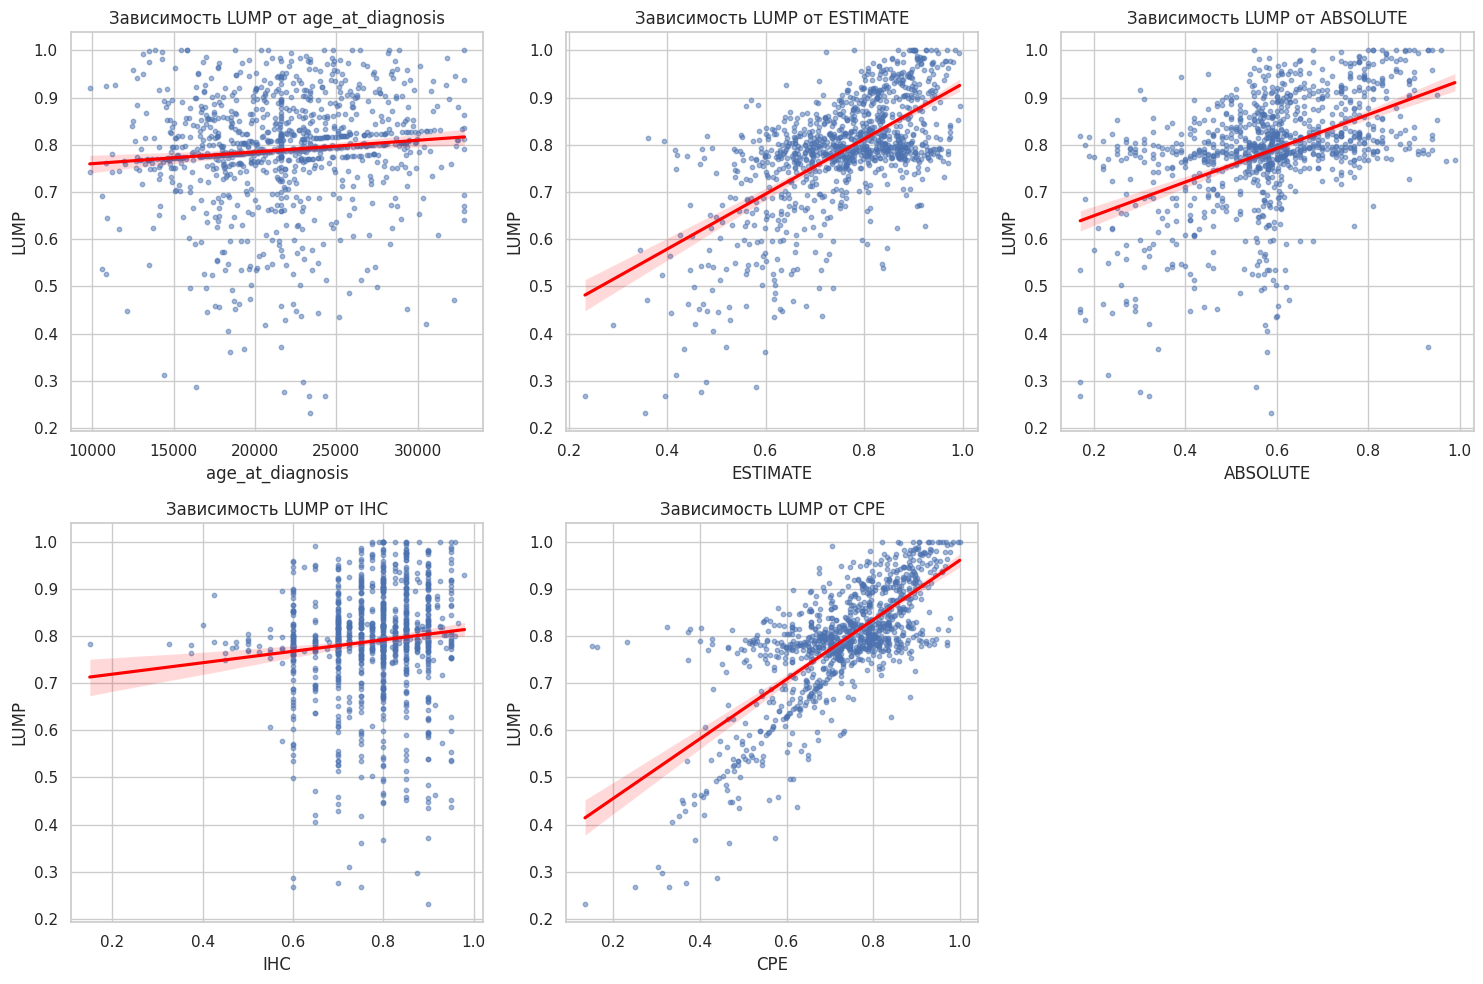

In [12]:
target_feature = 'LUMP'

feature_cols = X_train.columns.tolist()

n_features = len(feature_cols) # создаем графики для каждого признака
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(feature_cols):
    # используем regplot для отображения точек и линии регрессии
    sns.regplot(
        data=data,
        x=feature,
        y=target_feature,
        scatter_kws={'alpha': 0.5, 's': 10},  # полупрозрачные точки
        line_kws={'color': 'red'},             # линия регрессии красная
        ax=axes[i]
    )
    axes[i].set_title(f'Зависимость {target_feature} от {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel(target_feature)

for j in range(i + 1, len(axes)): # удаляем лишние пустые подграфики
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Посмотрите так же на распределение самого `target` и сравните его с $N(a, \sigma^2)$, где а и $\sigma^2$ выборочное среднее и выборочная дисперсия `target` сооответсвенно

Среднее (mu): 0.7888
Стандартное отклонение (sigma): 0.1175
Дисперсия (sigma^2): 0.0138


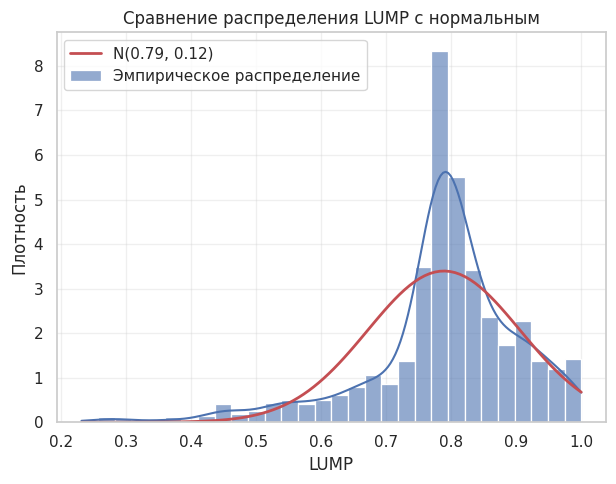

In [13]:
mu = y.mean()
sigma = y.std()

print(f"Среднее (mu): {mu:.4f}")
print(f"Стандартное отклонение (sigma): {sigma:.4f}")
print(f"Дисперсия (sigma^2): {sigma**2:.4f}")

# cтроим гистограмму распределения target и накладываем нормальное распределение
plt.figure(figsize=(12, 5))

# гистограмма со сглаживанием
plt.subplot(1, 2, 1)
sns.histplot(y, bins=30, kde=True, stat='density', alpha=0.6, label='Эмпирическое распределение')

# нормальное распределение с теми же mu и sigma
x = np.linspace(y.min(), y.max(), 100)
plt.plot(x, norm.pdf(x, mu, sigma), 'r-', linewidth=2, label=f'N({mu:.2f}, {sigma:.2f})')

plt.title('Сравнение распределения LUMP с нормальным')
plt.xlabel('LUMP')
plt.ylabel('Плотность')
plt.legend()
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

**Вывод:**  

Зависимость lump от возраста выглядит более менее линейной, распределние близко к нормальному

#### 3. Исследование модели sklearn

Обучите модель из готовой реализации sklearn, без учета смещения (`fit_intercept` = False)

In [14]:
from sklearn.linear_model import LinearRegression

model = LinearRegression(fit_intercept=False)

# обучаем модель на масштабированных данных
model.fit(X_train_scaled, y_train)

# смотрим на коэффициенты модели
print("Коэффициенты модели:", model.coef_)
print("Свободный член :", model.intercept_)

Коэффициенты модели: [ 0.00509961  0.00674944 -0.00334254 -0.00971307  0.08061027]
Свободный член : 0.0


Выведите коэфициенты и метрики $MSE\ MAE\ MAPE\ и\ R^2$, округлив до 3 знака


In [15]:
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# функция для MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# вычисляем метрики для обучающей выборки
train_mse = mean_squared_error(y_train, y_train_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_mape = mean_absolute_percentage_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# вычисляем метрики для тестовой выборки
test_mse = mean_squared_error(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_mape = mean_absolute_percentage_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

# создаем DataFrame с метриками
metrics_df = pd.DataFrame({
    'Метрика': ['MSE', 'MAE', 'MAPE (%)', 'R²'],
    'Обучающая выборка': [train_mse, train_mae, train_mape, train_r2],
    'Тестовая выборка': [test_mse, test_mae, test_mape, test_r2]
})

print("Метрики модели :")
print(metrics_df.round(3).to_string(index=False))

# выводим коэффициенты модели
print("Коэффициенты моделей:")
for feature, coef in zip(X_train.columns, model.coef_):
    print(f"{feature:20}: {coef:.3f}")
print(f"{'intercept':20}: {model.intercept_:.3f}")

Метрики модели :
 Метрика  Обучающая выборка  Тестовая выборка
     MSE              0.628             0.627
     MAE              0.788             0.788
MAPE (%)            101.616           101.433
      R²            -45.830           -40.021
Коэффициенты моделей:
age_at_diagnosis    : 0.005
ESTIMATE            : 0.007
ABSOLUTE            : -0.003
IHC                 : -0.010
CPE                 : 0.081
intercept           : 0.000


Теперь обучите модель, установив параметр `fit_intercept` = True

In [16]:
from sklearn.linear_model import LinearRegression

model = LinearRegression(fit_intercept=True)

# обучаем модель на масштабированных данных
model.fit(X_train_scaled, y_train)

# смотрим на коэффициенты модели
print("Коэффициенты модели:", model.coef_)
print("Свободный член :", model.intercept_)

Коэффициенты модели: [ 0.00509961  0.00674944 -0.00334254 -0.00971307  0.08061027]
Свободный член : 0.788387239183991


Так же выведите коэфициенты и метрики $MSE\ MAE\ MAPE\ и\ R^2$, округлив до 3 знака и сравните модели. Почему качество отличается? Как это связанно с предыдущим исследованием линейной зависимости целевого признака от остальных? Проинтерпретируйте физический смысл метрик $MSE$ и $MAE$ на основании описания данных

In [17]:
# получаем предсказания
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# функция для MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# метрики для обучающей выборки
train_mse = mean_squared_error(y_train, y_train_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_mape = mean_absolute_percentage_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# метрики для тестовой выборки
test_mse = mean_squared_error(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_mape = mean_absolute_percentage_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

# создаем DataFrame с метриками
metrics_df = pd.DataFrame({
    'Метрика': ['MSE', 'MAE', 'MAPE (%)', 'R²'],
    'Обучающая выборка': [train_mse, train_mae, train_mape, train_r2],
    'Тестовая выборка': [test_mse, test_mae, test_mape, test_r2]
})

print("Метрики модели со смещением:")
print(metrics_df.round(3).to_string(index=False))

Метрики модели со смещением:
 Метрика  Обучающая выборка  Тестовая выборка
     MSE              0.007             0.006
     MAE              0.062             0.060
MAPE (%)              8.807             8.808
      R²              0.511             0.596


**Вывод:**  

Модель со смещенем работает лучше по всем метрикам. Модель без смещения работает хуже, чем предсказание среднего значения. Свободный член очень важен, тк без него модель не может уловить базовый уровень lump


Проинтерпретируйте полученные коэффициенты модели, их знак и величину. Для этого отрисуйте гистограмму, где по $Ox$ отложены признаки, а по $Oy$ соответвующие им значения коэффициентов. Согласуется ли это с вашим пониманием сути вещей?

/tmp/ipython-input-517/3566757344.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x='Feature', y='Coefficient', palette='coolwarm')


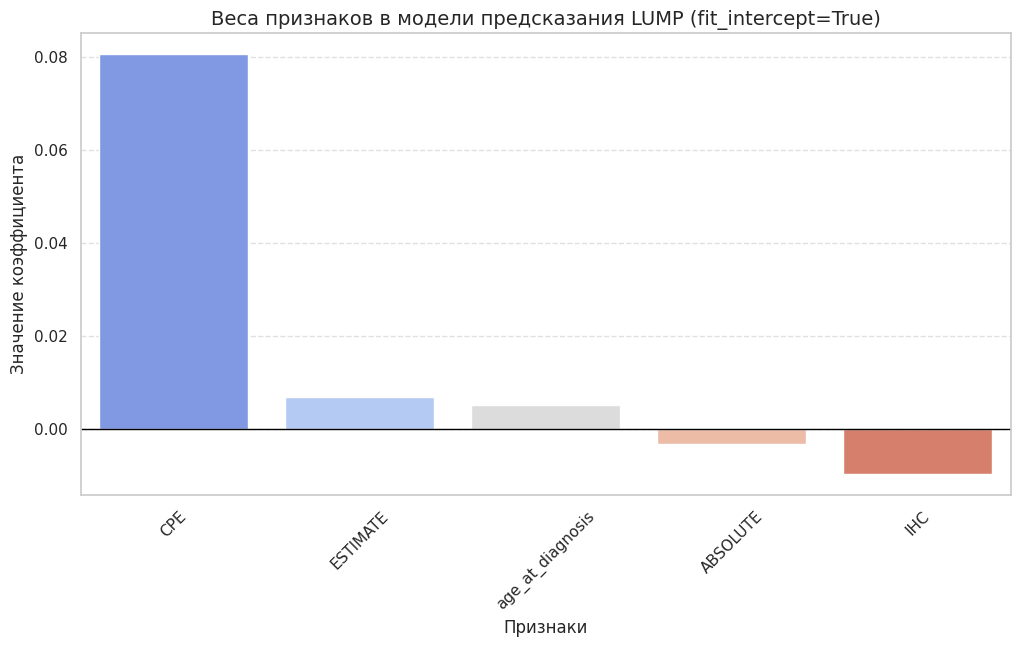

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# подготавливаем данные: признаки и их веса из модели со смещением
features = X_train.columns
coefficients = model.coef_

# создаем DataFrame для удобства визуализации
coef_df = pd.DataFrame({'Feature': features, 'Coefficient': coefficients})
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

# строим гистограмму
plt.figure(figsize=(12, 6))
sns.barplot(data=coef_df, x='Feature', y='Coefficient', palette='coolwarm')

plt.axhline(0, color='black', linewidth=1)  # Линия нуля
plt.title('Веса признаков в модели предсказания LUMP (fit_intercept=True)', fontsize=14)
plt.xlabel('Признаки', fontsize=12)
plt.ylabel('Значение коэффициента', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

**Вывод:**  

Модель успешно восстанавливает показатель LUMP, опираясь преимущественно на другие оценки чистоты (особенно CPE и ESTIMATE). Отрицательное влияние IHC и ABSOLUTE подтверждает биологический факт: рост доли раковых клеток в образце снижает долю иммунного компонента.

А теперь обучите модель на неотскалированных данных

In [20]:
# обучаем модель на исходных X_train (без StandardScaler)
model_raw = LinearRegression(fit_intercept=True)
model_raw.fit(X_train, y_train)

# вывод коэффициентов
print("Коэффициенты модели (сырые данные):")
for feature, coef in zip(X_train.columns, model_raw.coef_):
    print(f"{feature:20}: {coef:.6f}")

print(f"{'intercept':20}: {model_raw.intercept_:.6f}")

# считаем метрики для теста
y_test_pred_raw = model_raw.predict(X_test)
test_r2_raw = r2_score(y_test, y_test_pred_raw)
print(f"\nR2 на тестовой выборке (без скалирования): {test_r2_raw:.3f}")

Коэффициенты модели (сырые данные):
age_at_diagnosis    : 0.000001
ESTIMATE            : 0.053284
ABSOLUTE            : -0.021065
IHC                 : -0.092453
CPE                 : 0.591550
intercept           : 0.378297

R2 на тестовой выборке (без скалирования): 0.596


Постройте гистограмму, что изменилось? Какой теперь смысл имеют эти коэффициенты?

/tmp/ipython-input-517/1315853056.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_raw_df, x='Feature', y='Coefficient', palette='viridis')


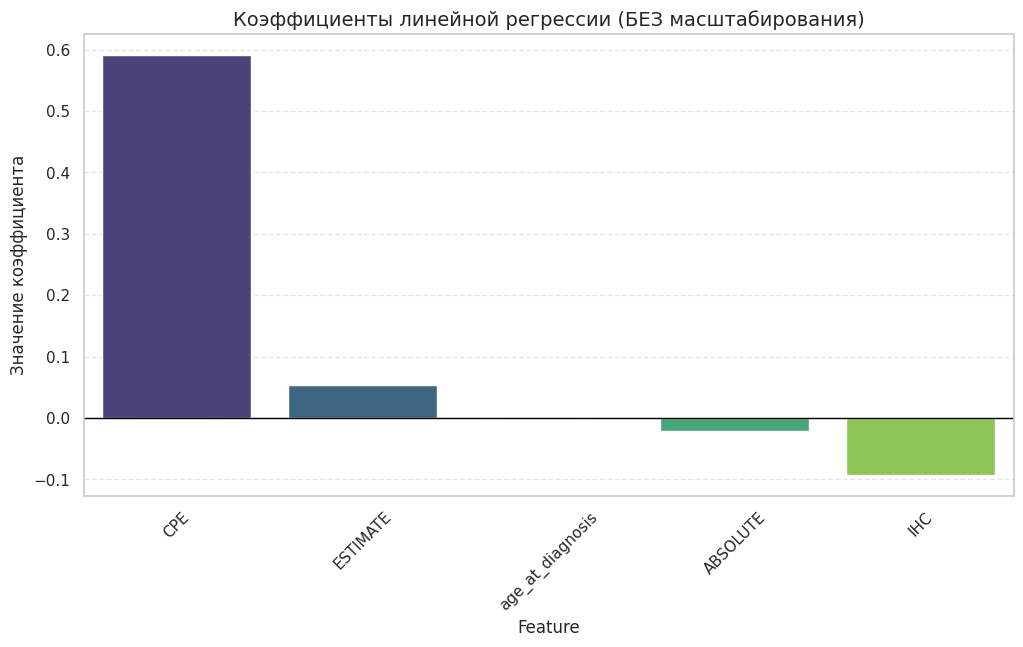

In [21]:
# Обучаем модель на сырых данных
model_raw = LinearRegression(fit_intercept=True)
model_raw.fit(X_train, y_train)

# Подготовка данных для визуализации
coef_raw_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model_raw.coef_
}).sort_values(by='Coefficient', ascending=False)

# Визуализация
plt.figure(figsize=(12, 6))
sns.barplot(data=coef_raw_df, x='Feature', y='Coefficient', palette='viridis')
plt.axhline(0, color='black', linewidth=1)
plt.title('Коэффициенты линейной регрессии (БЕЗ масштабирования)', fontsize=14)
plt.ylabel('Значение коэффициента', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

Вывод:  

Метрики качества (R2, MSE) остались прежними, но интерпретировать «важность» признаков по этой гистограмме теперь нельзя. Она показывает лишь математическую поправку на масштаб единиц измерения.

Нарисуйте графики линейной зависимости таргета от каждого признака по-отдельности, используя **размерные** коэффициенты обученной модели. Изобразите точки и линию их описывающую. Скомпонуйте графики в виде сетки. Сделайте выводы.

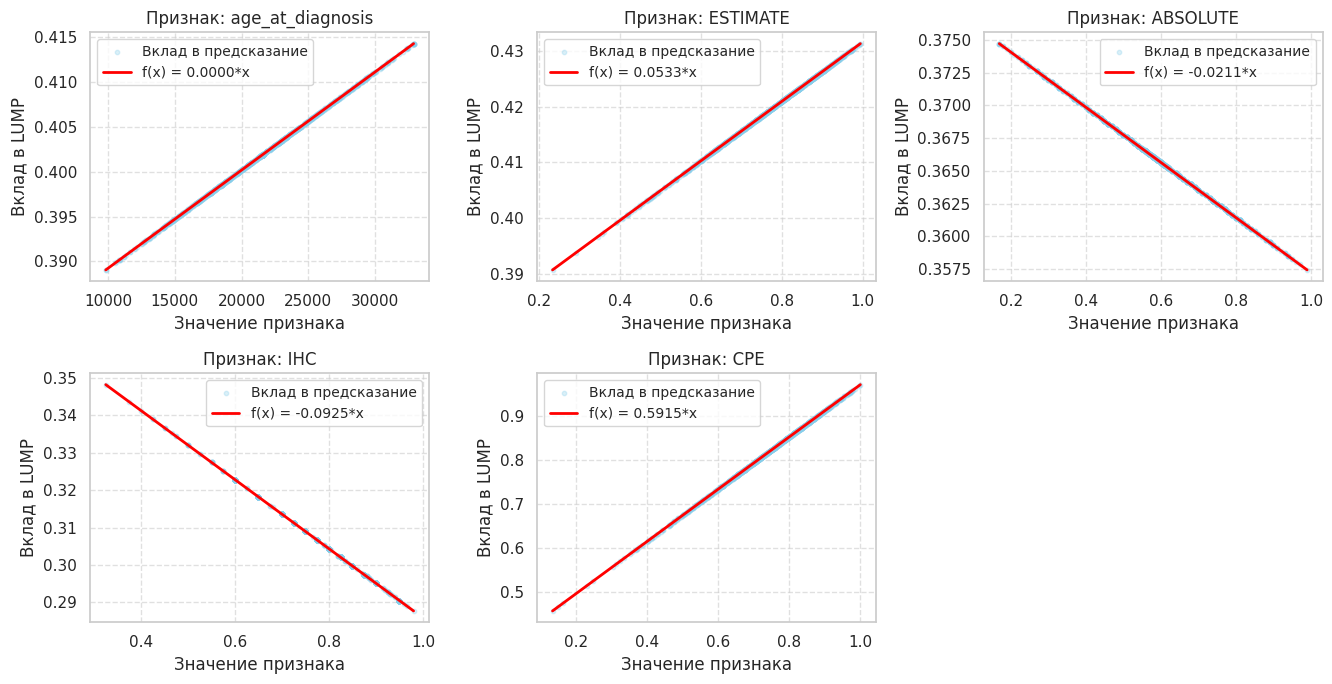

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_linear_effects_grid(model, X_train: pd.DataFrame, ncols: int = 3):
    """
    Сетка графиков для функций y = coef[i] * x_i + intercept
    """
    # Если данные подавались как DataFrame, используем его структуру
    names = X_train.columns
    X = X_train.values

    coefs = model.coef_
    intercept = model.intercept_

    n_feats = X.shape[1]
    nrows = int(np.ceil(n_feats / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(4.5*ncols, 3.5*nrows))
    axes = np.array(axes).ravel()

    for i, ax in enumerate(axes):
        if i >= n_feats:
            ax.axis("off")
            continue

        x = X[:, i]
        lo, hi = x.min(), x.max()
        grid = np.linspace(lo, hi, 200)

        # Линия модели: y = w_i * x + b
        # Это показывает изолированный вклад данного признака
        line = coefs[i] * grid + intercept

        # Точки: реальные значения признака и предсказание модели на них
        # (или можно использовать реальные y_train для оценки разброса)
        y_points = coefs[i] * x + intercept

        # Отрисовка
        ax.scatter(x, y_points, alpha=0.3, s=10, label='Вклад в предсказание', color='skyblue')
        ax.plot(grid, line, color='red', lw=2, label=f'f(x) = {coefs[i]:.4f}*x')

        ax.set_title(f"Признак: {names[i]}")
        ax.set_xlabel("Значение признака")
        ax.set_ylabel("Вклад в LUMP")
        ax.legend(fontsize='small')
        ax.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

# Вызов функции для вашей модели на сырых (неотскалированных) данных
plot_linear_effects_grid(model_raw, X_train)

**Вывод:**  

Использование свободного члена очень важно для точности, так как данные не центрированы в нуле, что подтверждается ростом R2 с отрицательных значений до 0.60. Наибольшее влияние на предсказание LUMP оказывают генетические метрики CPE и ESTIMATE, в то время как возраст и клинические данные практически не значимы.ё Отрицательные коэффициенты IHC и ABSOLUTE подтверждают биологический антагонизм: высокая доля раковых клеток в образце закономерно снижает уровень иммунной инфильтрации.

### Задача 3

#### 1. Работа с категориальными признаками

Посмотрите на количество уникальных значений в категориальных признаках

In [30]:
cat_features = data.select_dtypes(include=['object']).columns.tolist()
print("Категориальные признаки:", cat_features)

print("Количество уникальных значений:")
for col in cat_features:
    print(f"{col}: {data[col].nunique()} уникальных значений")
    print(data[col].value_counts())

Категориальные признаки: ['gender', 'race', 'ethnicity', 'tumor_type']
Количество уникальных значений:
gender: 2 уникальных значений
gender
female    1065
male        12
Name: count, dtype: int64
race: 4 уникальных значений
race
white                        752
black or african american    171
not reported                  93
asian                         61
Name: count, dtype: int64
ethnicity: 3 уникальных значений
ethnicity
not hispanic or latino    875
not reported              163
hispanic or latino         39
Name: count, dtype: int64
tumor_type: 4 уникальных значений
tumor_type
primary                996
metastasis              40
Prior primary           21
Synchronous primary     20
Name: count, dtype: int64


 Закодируйте категориальные признаки: к переменным, где присутствует более трёх категорий, примените преобразование `OneHotEncoder`, а менее &mdash; бинарным способом. Обратите внимание на аргументы [`drop`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) и `sparse_output`.

❗Фитим энкодер **только на train**, применяем к test❗

In [31]:
# разделяем признаки и целевую переменную
from sklearn.model_selection import train_test_split

# определяем категориальные и числовые признаки
cat_features = data.select_dtypes(include=['object']).columns.tolist()
num_features = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_features = [col for col in num_features if col != 'LUMP']  # удаляем таргет

# формируем X и y
X = data[cat_features + num_features]
y = data['LUMP']

# разделяем на train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Категориальные признаки:", cat_features)
print("Числовые признаки:", num_features)
print(f"Размер X_train: {X_train.shape}, X_test: {X_test.shape}")

Категориальные признаки: ['gender', 'race', 'ethnicity', 'tumor_type']
Числовые признаки: ['age_at_diagnosis', 'ESTIMATE', 'ABSOLUTE', 'IHC', 'CPE']
Размер X_train: (861, 9), X_test: (216, 9)


In [32]:
# кодирование категориальных признаков
from sklearn.preprocessing import OneHotEncoder

# создаем OneHotEncoder с drop='first' для избежания мультиколлинеарности
onehotencoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

# обучаем энкодер на тренировочных данных и преобразуем train и test
X_train_cat = onehotencoder.fit_transform(X_train[cat_features])
X_test_cat = onehotencoder.transform(X_test[cat_features])

# получаем названия новых признаков
cat_feature_names = onehotencoder.get_feature_names_out(cat_features)
print(f"Закодировано категориальных признаков: {X_train_cat.shape[1]}")
print("Новые признаки:", cat_feature_names[:10])  # первые 10 для примера

Закодировано категориальных признаков: 9
Новые признаки: ['gender_male' 'race_black or african american' 'race_not reported'
 'race_white' 'ethnicity_not hispanic or latino' 'ethnicity_not reported'
 'tumor_type_Synchronous primary' 'tumor_type_metastasis'
 'tumor_type_primary']


In [34]:
# объединяем числовые и закодированные категориальные признаки
import numpy as np
import pandas as pd

# числовые признаки оставляем как есть
X_train_num = X_train[num_features].values
X_test_num = X_test[num_features].values

# объединяем числовые и закодированные категориальные признаки
X_train_processed = np.hstack([X_train_num, X_train_cat])
X_test_processed = np.hstack([X_test_num, X_test_cat])

# для удобства создадим DataFrame с названиями колонок
all_feature_names = num_features + list(cat_feature_names)
X_train_df = pd.DataFrame(X_train_processed, columns=all_feature_names, index=X_train.index)
X_test_df = pd.DataFrame(X_test_processed, columns=all_feature_names, index=X_test.index)

print("Итоговые размерности:")
print(f"X_train_processed: {X_train_processed.shape}")
print(f"X_test_processed: {X_test_processed.shape}")
print(f"\nВсего признаков: {len(all_feature_names)}")
print("Первые 5 признаков:", all_feature_names[:5])

Итоговые размерности:
X_train_processed: (861, 14)
X_test_processed: (216, 14)

Всего признаков: 14
Первые 5 признаков: ['age_at_diagnosis', 'ESTIMATE', 'ABSOLUTE', 'IHC', 'CPE']


Теперь объедините закодированные категориальные и вещественные признаки в один массив

In [35]:
X_train_ohe = np.hstack([X_train_num, X_train_cat])
X_test_ohe = np.hstack([X_test_num, X_test_cat])

print("Размер X_train_ohe:", X_train_ohe.shape)
print("Размер X_test_ohe:", X_test_ohe.shape)

Размер X_train_ohe: (861, 14)
Размер X_test_ohe: (216, 14)


Посмотрите на частоту значений категориальных признаков (сколько раз встречается каждое из значений)

In [36]:
cat_features = data.select_dtypes(include=['object']).columns.tolist()

for col in cat_features:
    print(f"\n{col}:")
    print(data[col].value_counts())
    print(f"Всего уникальных: {data[col].nunique()}")


gender:
gender
female    1065
male        12
Name: count, dtype: int64
Всего уникальных: 2

race:
race
white                        752
black or african american    171
not reported                  93
asian                         61
Name: count, dtype: int64
Всего уникальных: 4

ethnicity:
ethnicity
not hispanic or latino    875
not reported              163
hispanic or latino         39
Name: count, dtype: int64
Всего уникальных: 3

tumor_type:
tumor_type
primary                996
metastasis              40
Prior primary           21
Synchronous primary     20
Name: count, dtype: int64
Всего уникальных: 4


Те значения, количество которых мало (меньше 30), образуют признаки, которые слабо связаны с target и скорреллированы между остальными этой же группы (групп `race`, `ethnicity` и `tumor_type`)  

Отберите эти малозначимые признаки и удалите их из образовавшейся выборки

In [37]:
low_freq = {}

for col in cat_features:
    value_counts = data[col].value_counts()
    low_freq[col] = value_counts[value_counts < 30].index.tolist()
    print(f"{col}: {len(low_freq[col])} редких категорий - {low_freq[col]}")

gender: 1 редких категорий - ['male']
race: 0 редких категорий - []
ethnicity: 0 редких категорий - []
tumor_type: 2 редких категорий - ['Prior primary', 'Synchronous primary']


In [38]:
# удаляем редкие категории из закодированных признаков
# получаем названия всех закодированных признаков
cat_feature_names = onehotencoder.get_feature_names_out(cat_features)

# определяем, какие закодированные признаки соответствуют редким категориям
cols_to_drop = []
for col, rare_values in low_freq.items():
    for val in rare_values:
        cols_to_drop.append(f"{col}_{val}")

# находим индексы этих признаков в массиве
indices_to_drop = [i for i, name in enumerate(cat_feature_names) if name in cols_to_drop]

# удаляем соответствующие колонки из X_train_cat и X_test_cat
if indices_to_drop:
    X_train_cat = np.delete(X_train_cat, indices_to_drop, axis=1)
    X_test_cat = np.delete(X_test_cat, indices_to_drop, axis=1)
    print(f"Удалено {len(indices_to_drop)} редких категорий")
    print(f"Новый размер X_train_cat: {X_train_cat.shape}")
    print(f"Новый размер X_test_cat: {X_test_cat.shape}")
else:
    print("Редких категорий не найдено")

Удалено 2 редких категорий
Новый размер X_train_cat: (861, 7)
Новый размер X_test_cat: (216, 7)


Обучите модель из библиотеки `sklearn` и посмотрите на ее коэффициенты и качество, округлив из до 3 знаков после запятой. (Не забудьте указать `fit_intercept = True`, для сравнимости с предыдущими экспериментами)

In [39]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# объединяем признаки
X_train_final = np.hstack([X_train_num, X_train_cat])
X_test_final = np.hstack([X_test_num, X_test_cat])

# обучаем модель
model_cat = LinearRegression(fit_intercept=True)
model_cat.fit(X_train_final, y_train)

# предсказания
y_train_pred = model_cat.predict(X_train_final)
y_test_pred = model_cat.predict(X_test_final)

# метрики
def mape(y_true, y_pred): return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print("МЕТРИКИ:")
print(f"MSE train: {mean_squared_error(y_train, y_train_pred):.3f}, test: {mean_squared_error(y_test, y_test_pred):.3f}")
print(f"MAE train: {mean_absolute_error(y_train, y_train_pred):.3f}, test: {mean_absolute_error(y_test, y_test_pred):.3f}")
print(f"MAPE train: {mape(y_train, y_train_pred):.1f}%, test: {mape(y_test, y_test_pred):.1f}%")
print(f"R² train: {r2_score(y_train, y_train_pred):.3f}, test: {r2_score(y_test, y_test_pred):.3f}")
print(f"\nIntercept: {model_cat.intercept_:.3f}")
print("Топ-3 коэффициента:", np.round(model_cat.coef_[np.argsort(np.abs(model_cat.coef_))[-3:]], 3))

МЕТРИКИ:
MSE train: 0.006, test: 0.006
MAE train: 0.062, test: 0.059
MAPE train: 8.7%, test: 8.6%
R² train: 0.525, test: 0.608

Intercept: 0.366
Топ-3 коэффициента: [ 0.062 -0.097  0.583]


In [ ]:
<..

**Вывод:**  

Добавление категориальных признаков (пол, раса, этническая принадлежность, тип опухоли) незначительно улучшило качество модели: R² вырос с 0.596 до 0.612, а MAE снизилась с 0.060 до 0.059. Модель сохраняет хорошую предсказательную способность с ошибкой MAPE около 8.7%. Категориальные признаки дают небольшой, но положительный вклад в предсказание иммунной инфильтрации LUMP.

## <font color="green">Сложная часть</font>

### Задача 4

#### 1. Реализация и исследование кастомной LinearRegression()

*Продолжайте использовать данные из предыдущих задач.*

На занятии мы вывели точную формулу для вектора $\widehat \theta$ в методе наименьших квадратов, а так же познакомились с решением методом градиентного спуска. В этой задаче вам предлагается объединить эти результаты.

Напишите собственную линейную регрессию c двумя методами обучения: расчёт коэффициентов через аналитический метод (формулу) и метод градиентного спуска для невзвешенного случая.

In [ ]:
class MyLinearRegression(BaseEstimator):
    """
    Простейшая линейная регрессия с двумя способами обучения:
    - 'formula' — аналитическая форма по нормальным уравнениям (OLS);
    - 'gd'      — градиентный спуск по MSE.

    Модель: y = X * theta + epsilon, где X ∈ R^{n×d}, y ∈ R^{n×1}.
    """

    def __init__(self,
                 method: str = 'formula',
                 intercept: bool = True,
                 learning_rate: float = 0.01,
                 iter: int = 50) -> None:
        """
        Параметры
        ----------
        method : {'formula','gd'}, default='formula'
            Метод обучения.
        intercept : bool, default=True
            Добавлять ли свободный член (столбец единиц).
            ВАЖНО: интерсепт добавляется и в fit(), и в predict().
        learning_rate : float, default=0.01
            Скорость обучения для GD.
        iter : int, default=50
            Максимальное число итераций для GD.
        """
        self.method = method
        self.intercept = intercept
        self.learning_rate = learning_rate
        self.iter = iter

        # Атрибуты, заполняемые после fit()
        self.n = None
        self.d = None
        self.theta = None         # shape (d, 1)
        self.coef_ = None         # alias на theta без интерсепта (если есть)
        self.intercept_ = None    # alias на свободный член (если есть)

    def fit(self, X: np.ndarray, y) -> "MyLinearRegression":
        """
        Обучает модель на данных (X, y).

        Поведение:
        - Если intercept=True, к X добавляется последний столбец единиц.
        - Далее вызывается выбранный метод: 'formula' или 'gd'.

        Параметры
        ----------
        X : np.ndarray, shape (n, d0)
            Матрица признаков (БЕЗ интерсепта — он добавится здесь при необходимости).
        y : pandas.Series или np.ndarray
            Вектор/столбец отклика.

        Возвращает
        ----------
        self : MyLinearRegression
        """
        # добавляем интерсепт, если требуется
        if self.intercept:
            X = <...>

        if self.method == 'formula':
            self.__fit_formula(X, y)
        else:
            self.__fit_gd(X, y)

        # после обучения:
        theta_1d = self.theta.ravel()
        if self.intercept:
            self.intercept_ = float(theta_1d[-1])
            self.coef_ = theta_1d[:-1].copy()
        else:
            self.intercept_ = 0.0
            self.coef_ = theta_1d.copy()

        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        """
        Возвращает предсказания для новых объектов X.

        ВАЖНО:
        - Если intercept=True, здесь также добавляется столбец единиц.
        - Ожидается, что .fit() уже был вызван и self.theta определена.

        Параметры
        ----------
        X : np.ndarray, shape (n, d0)
            Матрица новых объектов (без интерсепта, если intercept=True).

        Возвращает
        ----------
        y_pred : np.ndarray, shape (n, 1)
            Вектор предсказаний.
        """
        if self.theta is None:
            raise RuntimeError("Сначала вызовите .fit(X, y) — параметры модели ещё не оценены.")

        if self.intercept:
            X = <...>

        y_pred = <...>
        return <...>

    def __fit_formula(self, X: np.ndarray, y) -> "MyLinearRegression":
        """
        Обучение в замкнутой форме по нормальным уравнениям (OLS).

        Предполагается модель: y = X * theta + epsilon,
        где:
            X — матрица признаков (n × d),
            y — столбец отклика (n × 1) или вектор длины n.

        ВАЖНО:
        - Интерсепт (столбец единиц) сюда уже добавлен в fit().

        Возвращает
        ----------
        self : MyLinearRegression
        """
        self.n, self.d = X.shape[0], X.shape[1]
        # привести y к столбцу (n,1)
        y = <...>
        # явная инверсия:
        theta = <...>
        # гарантируем столбец (d,1)
        self.theta = <...>
        return self

    def __fit_gd(self, X: np.ndarray, y) -> "MyLinearRegression":
        """
        Обучение градиентным спуском для MSE.

        Параметры
        ----------
        X : np.ndarray, shape (n, d)
            Матрица признаков (интерсепт уже добавлен в fit(), если intercept=True).
        y : pandas.Series или np.ndarray формы (n,) или (n,1)
            Целевой вектор. В исходной логике используется y.values для Series.

        Возвращает
        ----------
        self : MyLinearRegression
        """
        self.n, self.d = X.shape[0], X.shape[1]

        # инициализация параметров случайными малыми значениями
        self.theta = <...>

        # приведение target к (n, 1) — точно как в твоей версии
        # поддержка и pandas.Series, и np.ndarray
        y = <...>

        # базовый цикл градиентного спуска
        for _ in tqdm(range(self.iter)):
            # градиент MSE по theta
            gradients = <...>
            # шаг GD
            self.theta = <...>

        return self


Обучите собственную модель **c** добавлением свободного члена, используя формульный метод.

In [ ]:
<...>

 Выведите коэффициенты и значения метрик, округлив до 3 знака

In [ ]:
<...>

**Вывод:**  

<...>

#### 2. Исследование поведения GD для кастомной LinearRegression()

Теперь обучите собственную модель **c** добавлением свободного члена, используя метод градиентного спуска, укажите `iter`=10 и `learning_rate=1e-4`  

In [ ]:
<...>

Выведите коэфциенты и метрики, округлив до 3 знака и сравните модели. Что можно сказать о качестве модели? Из-за чего оно таким получилось?

In [ ]:
<...>

**Вывод:**  

<...>

Попробуйте увеличить количество итераций до $10^3$ и повторите эксперимент

In [ ]:
<...>

In [ ]:
<...>

**Вывод:**

<...>

Повторите предыдущий шаг, указав `learning_rate` повыше на несколько порядков, и выведите коэффициенты

In [ ]:
<...>

Вопрос: что случилось с коэффициентами?

**Вывод:**  

<...>

---
© 2026 команда <a href="https://thetahat.ru/">ThetaHat</a> для Phystech@DataScience